# Capacidad de Planta vs. Rendimiento: Análisis de Portafolio en Dos Dimensiones con PROC SGPLOT

## Resumen Ejecutivo

Un portafolio de producción de manufactura discreta tiene dos números que importan para cada línea de producto a la vez: **cuánta capacidad de máquina consume** y **cuánto producto bueno realmente entrega**. Un gráfico de barras unidimensional solo puede mostrar uno de ellos. Este cuaderno visualiza ambos juntos con `PROC SGPLOT`, usando un **gráfico de burbujas** como vista central — cada línea se posiciona por capacidad (x) y rendimiento (y), con el tamaño de la burbuja codificando su tasa de productividad (unidades por hora-máquina). Las líneas que se ubican abajo-y-a-la-derecha (mucha capacidad, poco producto) son sumideros de capacidad; las líneas que se ubican arriba-y-a-la-izquierda con una burbuja grande son de alto rendimiento. Una vista de barras agrupadas luego descompone el rendimiento por planta, y una clasificación de productividad confirma la brecha.

Trabajando con la salida real ejecutada (ocho líneas de producto en tres plantas, 100 corridas a nivel de turno agregadas en 24 celdas línea-por-planta), el análisis encuentra que **Fundición** es el sumidero de capacidad más claro del portafolio (14.3 unidades buenas por hora-máquina — consume el 10.1% de la capacidad total pero entrega solo el 3.2% de las unidades buenas) mientras que **Empaquetado** es la línea de alto rendimiento sobresaliente (119.2 unidades por hora — el 9.1% de la capacidad devuelve el 23.8% del producto). Entre plantas, **Stuttgart** funciona más caliente con 49.9 unidades/hora y **Monterrey** la más fría con 41.6.

## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Corridas de producción sintéticas a nivel de turno en 8 líneas de producto, 3 plantas y 3 turnos — horas-máquina programadas, horas de corrida, tiempo de inactividad, unidades brutas/de desecho/buenas (limitado a 100 observaciones en modo sin licencia) | 100 |
| WORK.LINE_CAPACITY | Resumen agregado por línea de producto y planta: horas de capacidad total (x), unidades buenas producidas (y) y % de rendimiento de unidades aceptadas | 24 |

*Todos los datos son sintéticos y se generan en el cuaderno con una semilla fija — sin archivos externos, sin red.*

# Análisis de Capacidad de Planta vs. Rendimiento

**Dominio:** Manufactura discreta — operaciones / ingeniería industrial

**Procedimiento:** `PROC SGPLOT` (ODS Statistical Graphics)

Un gráfico de barras convencional muestra una sola respuesta por categoría. Para comparar un portafolio de producción en **dos** dimensiones numéricas a la vez — *cuánta capacidad consume cada línea de producto* frente a *cuánto producto realmente entrega* — necesitamos un gráfico que ubique ambas en el mismo lienzo. La instrucción `BUBBLE` de `PROC SGPLOT` hace exactamente eso: posiciona cada línea por capacidad (x) y unidades buenas (y) y deja que una tercera medida, la tasa de productividad, controle el tamaño de la burbuja. Una línea que se ubica muy a la derecha pero baja es un sumidero de capacidad; una línea que se ubica alta y a la izquierda con una burbuja grande es una línea de alto rendimiento que vale la pena proteger. Este cuaderno construye un conjunto de datos de producción sintético realista y ejecuta SGPLOT a través de un gráfico de burbujas, un gráfico de barras agrupado por planta, un detalle de una sola planta y una comparación de plantas en barras agrupadas lado a lado.

> **Una nota sobre PROC GAREABAR.** La forma clásica de SAS/GRAPH de codificar dos dimensiones por *barra* es `PROC GAREABAR` (un gráfico de área-barra solo ActiveX donde el ancho de la barra codifica una variable y la altura otra). GAREABAR **aún no está implementado en esta compilación de Jenner** — la brecha se rastrea en la prueba archivada `tests/400996_nb_gareabar_unimplemented`. Este cuaderno alcanza el mismo objetivo analítico con el `PROC SGPLOT` totalmente soportado, cuyas vistas de burbujas y barras agrupadas transmiten la misma historia de capacidad frente a rendimiento.

## 1. Generar datos de producción sintéticos

Simulamos seis semanas de corridas de producción a nivel de turno para una red de manufactura discreta de tres plantas. Cada línea de producto tiene un tiempo de ciclo base y una tasa de desecho; el rendimiento se rige por las horas-máquina programadas, la eficiencia específica de la línea y el tiempo de inactividad aleatorio. `call streaminit` fija la semilla para que el cuaderno sea totalmente reproducible — sin archivos externos, sin red.

In [1]:
/* --------------------------------------------------------
   Corridas de produccion sinteticas a nivel de turno
   8 lineas de producto x 3 plantas x 3 turnos x ~10 dias
   var de ancho  = horas-maquina programadas (capacidad)
   respuesta     = unidades buenas producidas (rendimiento)
   -------------------------------------------------------- */
DATOS work.production_runs;
    LLAMAR streaminit(20260531);
    LONGITUD product_line $20 plant $12 shift $8;

    /* unidades nominales producidas por hora-maquina, por linea */
    ARREGLO line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* fraccion base de desecho por linea */
    ARREGLO line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    /* multiplicador de eficiencia de planta */
    ARREGLO plant_eff[3] _temporary_ (1.00 0.92 1.08);
    ARREGLO shift_eff[3] _temporary_ (1.00 0.95 0.88);

    /* nombres de linea/planta/turno asignados con IF/ELSE (no con array
       _temporary_): un array _temporary_ con valores no ASCII truncaba
       los valores recuperados a un largo inconsistente */
    HACER day = 1 HASTA 10;
        HACER li = 1 HASTA 8;
            HACER pi = 1 HASTA 3;
                HACER si = 1 HASTA 3;
                    SI      li = 1 ENTONCES product_line = 'Estampado';
                    SINO SI li = 2 ENTONCES product_line = 'Soldadura';
                    SINO SI li = 3 ENTONCES product_line = 'Mecanizado';
                    SINO SI li = 4 ENTONCES product_line = 'Fundicion';
                    SINO SI li = 5 ENTONCES product_line = 'Inyeccion';
                    SINO SI li = 6 ENTONCES product_line = 'Ensamblaje';
                    SINO SI li = 7 ENTONCES product_line = 'Acabado';
                    SINO SI li = 8 ENTONCES product_line = 'Empaquetado';

                    SI      pi = 1 ENTONCES plant = 'Detroit';
                    SINO SI pi = 2 ENTONCES plant = 'Monterrey';
                    SINO SI pi = 3 ENTONCES plant = 'Stuttgart';

                    SI      si = 1 ENTONCES shift = 'Dia';
                    SINO SI si = 2 ENTONCES shift = 'Tarde';
                    SINO SI si = 3 ENTONCES shift = 'Noche';

                    /* horas-maquina programadas para el turno */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* el tiempo de inactividad no planificado reduce la capacidad */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* tasa de rendimiento efectiva con ruido */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    SALIDA;
                END;
            END;
        END;
    END;
    MANTENER run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    FORMATO run_date date9.;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.production_runs(obs=8) noobs;
    TÍTULO 'Muestra de corridas de produccion sinteticas a nivel de turno';
EJECUTAR;
TÍTULO;

                             Muestra de corridas de produccion sinteticas a nivel de turno                              

 run_date  product_line      plant  shift  sched_hours  run_hours  downtime_hours  gross_units  scrap_units  good_units
05JAN2026  Estampado     Detroit    Dia            7.8        6.7             1.1          306           14         292
05JAN2026  Estampado     Detroit    Tarde          6.8        6.5             0.3          259           12         247
05JAN2026  Estampado     Detroit    Noche            8        7.6             0.4          269           11         258
05JAN2026  Estampado     Monterrey  Dia            7.9        6.8             1.1          283           12         271
05JAN2026  Estampado     Monterrey  Tarde          7.5        6.9             0.6          254            9         245
05JAN2026  Estampado     Monterrey  Noche          7.4        6.9             0.5          253            8         245
05JAN2026  Estampado     Stuttgart  Di


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.24 seconds
  cpu   0.24 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. Agregar al nivel de línea y planta

Los gráficos comparan un punto por categoría, así que agregamos el detalle a nivel de turno en un resumen por línea de producto y planta. `total_capacity` (suma de horas-máquina programadas) se convierte en la dimensión **x**, `good_units` (suma de producto aceptado) en la dimensión **y**, y `units_per_hr` (unidades buenas ÷ horas de capacidad) en la tasa de productividad que dimensionará las burbujas. Conservamos `plant` para que sirva como variable de agrupación más adelante. También construimos un resumen a nivel de línea (a través de las plantas) para el gráfico de burbujas del portafolio.

In [2]:
/* --------------------------------------------------------
   Agregar a product_line x plant
   total_capacity -> x (horas de capacidad)
   good_units     -> y (rendimiento)
   units_per_hr   -> tamano de burbuja (productividad)
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.production_runs NOPRINT NWAY;
    CLASE product_line plant;
    VAR sched_hours good_units scrap_units;
    SALIDA out=work.line_capacity(ELIMINAR=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
EJECUTAR;

DATOS work.line_capacity;
    ESTABLECER work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    FORMATO units_per_hr 6.1 yield_pct 5.1;
EJECUTAR;

PROCEDIMIENTO ORDENAR DATOS=work.line_capacity;
    POR product_line plant;
EJECUTAR;

/* Resumen a nivel de linea (a traves de las tres plantas) para la vista de portafolio */
PROCEDIMIENTO MEDIAS DATOS=work.line_capacity NOPRINT NWAY;
    CLASE product_line;
    VAR total_capacity good_units;
    SALIDA out=work.line_total(ELIMINAR=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
EJECUTAR;

DATOS work.line_total;
    ESTABLECER work.line_total;
    units_per_hr = good_units / total_capacity;
    FORMATO units_per_hr 6.1;
EJECUTAR;

PROCEDIMIENTO ORDENAR DATOS=work.line_total;
    POR units_per_hr;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.line_total noobs;
    VAR product_line total_capacity good_units units_per_hr;
    TÍTULO 'Lineas del portafolio clasificadas por productividad (unidades buenas por hora-maquina)';
EJECUTAR;
TÍTULO;

                Lineas del portafolio clasificadas por productividad (unidades buenas por hora-maquina)                 

product_line  total_capacity  good_units  units_per_hr
Fundicion               73.4        1050          14.3
Soldadura              130.8        3038          23.2
Mecanizado             128.9        3762          29.2
Estampado              130.7        4713          36.1
Inyeccion               66.2        3430          51.8
Ensamblaje              67.3        4289          63.7
Acabado                 64.6        4927          76.3
Empaquetado             65.9        7855         119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. Abrir el destino de ODS Graphics

`PROC SGPLOT` se renderiza a través de ODS Statistical Graphics. Abrimos un destino `ODS HTML` para que cada gráfico se emita como una imagen, y activamos `ODS GRAPHICS ON`. No se requiere ningún controlador de dispositivo especial — SGPLOT es independiente del dispositivo, a diferencia de los procedimientos SAS/GRAPH solo ActiveX.

In [3]:
ODS html;
ODS GRAPHICS ON;


NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Gráfico de burbujas del portafolio — capacidad vs. rendimiento

La vista central: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Cada línea de producto es una burbuja, posicionada por horas de capacidad total (x) y unidades buenas totales (y), con el área de la burbuja escalada a su tasa de productividad. `DATALABEL=` imprime el nombre de la línea junto a cada burbuja. Esta es la comparación bidimensional que un gerente de planta quiere — los sumideros de capacidad caen hacia la **parte inferior derecha** (muchas horas, poco producto, burbuja pequeña); las líneas de alto rendimiento suben hacia la **parte superior izquierda** (pocas horas, mucho producto, burbuja grande).

                                  Portafolio de Produccion - Capacidad vs. Rendimiento                                  
               x = horas-maquina programadas; y = unidades buenas; tamano de burbuja = unidades por hora                


Abajo a la derecha = sumidero de capacidad; arriba a la izquierda con burbuja grande = linea de alto rendimiento.



NOTE: Option TITLE changed to Portafolio de Produccion - Capacidad vs. Rendimiento.
NOTE: Option TITLE2 changed to x = horas-maquina programadas; y = unidades buenas; tamano de burbuja = unidades por hora.
NOTE: Option FOOTNOTE changed to Abajo a la derecha = sumidero de capacidad; arriba a la izquierda con burbuja grande = linea de alto rendimiento..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


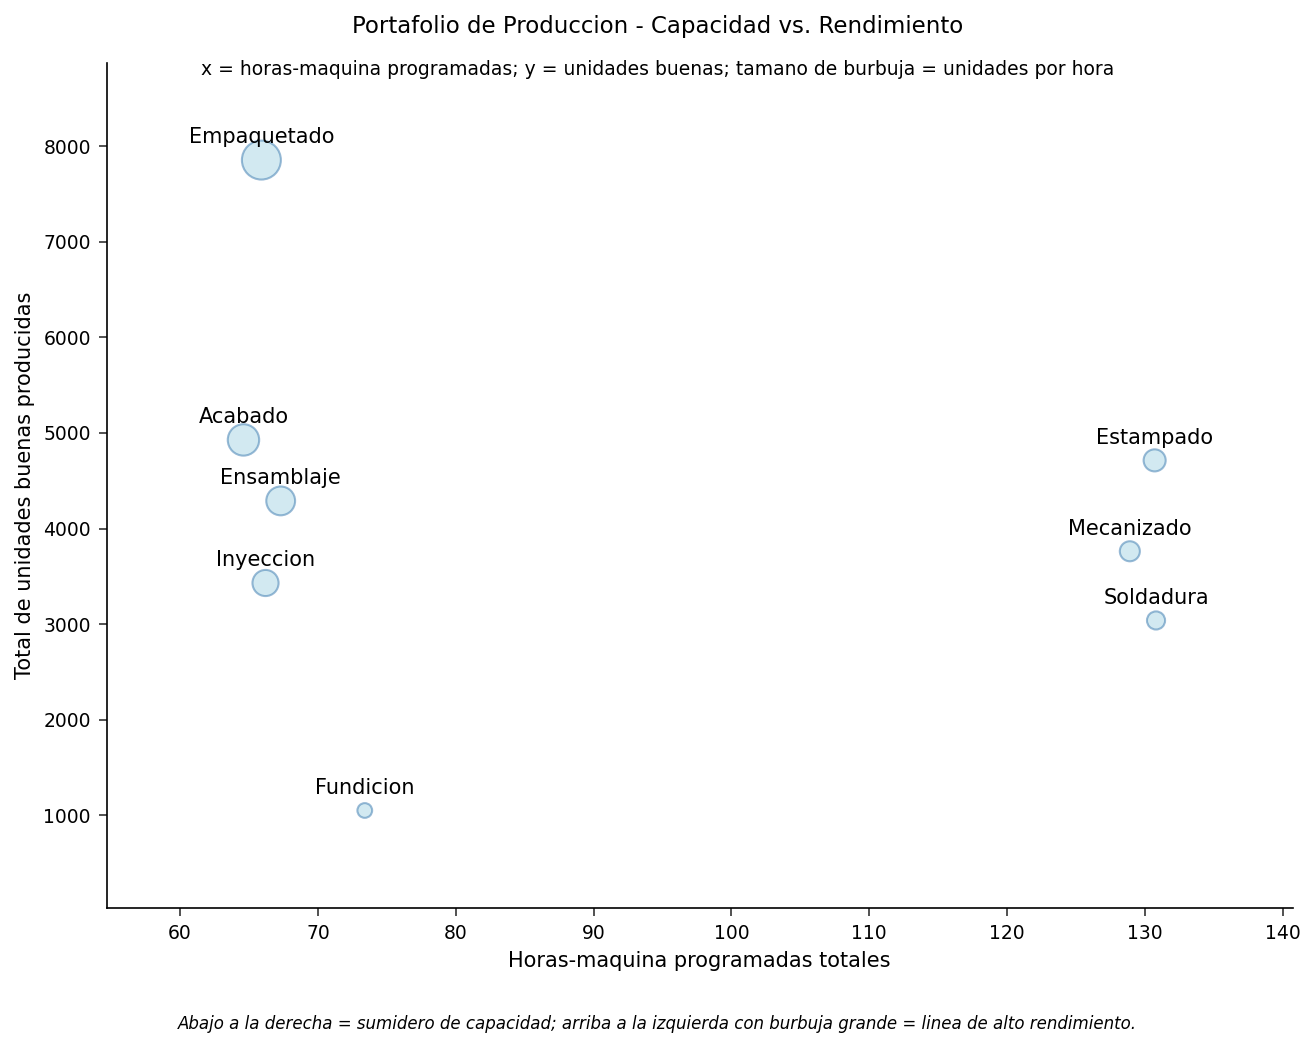

In [4]:
TÍTULO 'Portafolio de Produccion - Capacidad vs. Rendimiento';
title2 'x = horas-maquina programadas; y = unidades buenas; tamano de burbuja = unidades por hora';
footnote JUSTIFY=LEFT
    'Abajo a la derecha = sumidero de capacidad; arriba a la izquierda con burbuja grande = linea de alto rendimiento.';

PROCEDIMIENTO SGPLOT DATOS=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS ETIQUETA='Horas-maquina programadas totales';
    YAXIS ETIQUETA='Total de unidades buenas producidas';
EJECUTAR;

TÍTULO; title2; footnote;

## 5. Rendimiento por línea, descompuesto por planta

Para ver cómo se divide la producción de cada línea entre las tres plantas, un gráfico `VBAR product_line / response=good_units group=plant` apila las contribuciones de cada planta dentro de cada barra. Esta es la vista de segmentación: muestra tanto la altura total (unidades buenas por línea) como la mezcla de plantas dentro de cada barra, para detectar líneas donde una planta domina la producción.

                               Unidades Buenas por Linea de Producto, Apiladas por Planta                               
                     Altura de barra = total de unidades buenas; segmentos = contribucion de planta                     




NOTE: Option TITLE changed to Unidades Buenas por Linea de Producto, Apiladas por Planta.
NOTE: Option TITLE2 changed to Altura de barra = total de unidades buenas; segmentos = contribucion de planta.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


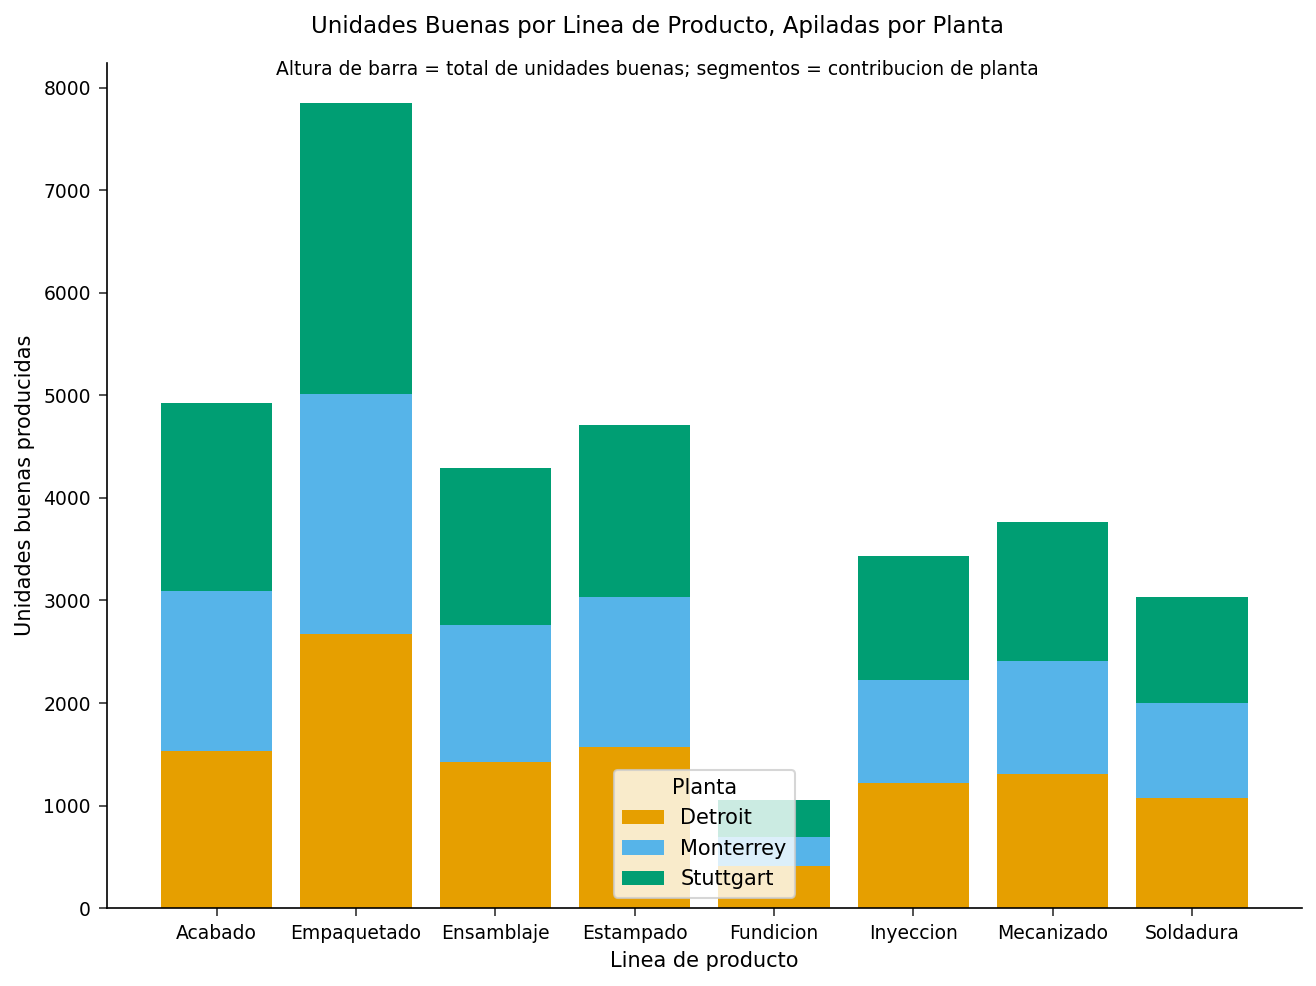

In [5]:
TÍTULO 'Unidades Buenas por Linea de Producto, Apiladas por Planta';
title2 'Altura de barra = total de unidades buenas; segmentos = contribucion de planta';

PROCEDIMIENTO SGPLOT DATOS=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS ETIQUETA='Linea de producto' fitpolicy=ROTATE;
    YAXIS ETIQUETA='Unidades buenas producidas';
    keylegend / TÍTULO='Planta' position=bottom;
EJECUTAR;

TÍTULO; title2;

## 6. Detalle de productividad de una sola planta (WHERE)

Las barras horizontales (`HBAR`) son adecuadas para etiquetas de línea de producto largas. Una cláusula `WHERE` filtra a la planta de Stuttgart, y las barras se dibujan para `units_per_hr` de modo que el gráfico clasifica las líneas de Stuttgart por productividad. Como la entrada está ordenada ascendentemente por tasa, la línea menos productiva queda abajo y la más productiva arriba.

                              Planta de Stuttgart - Lineas Clasificadas por Productividad                               


Longitud de barra = unidades buenas por hora-maquina (detalle de una sola planta).



NOTE: Option TITLE changed to Planta de Stuttgart - Lineas Clasificadas por Productividad.
NOTE: Option FOOTNOTE changed to Longitud de barra = unidades buenas por hora-maquina (detalle de una sola planta)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


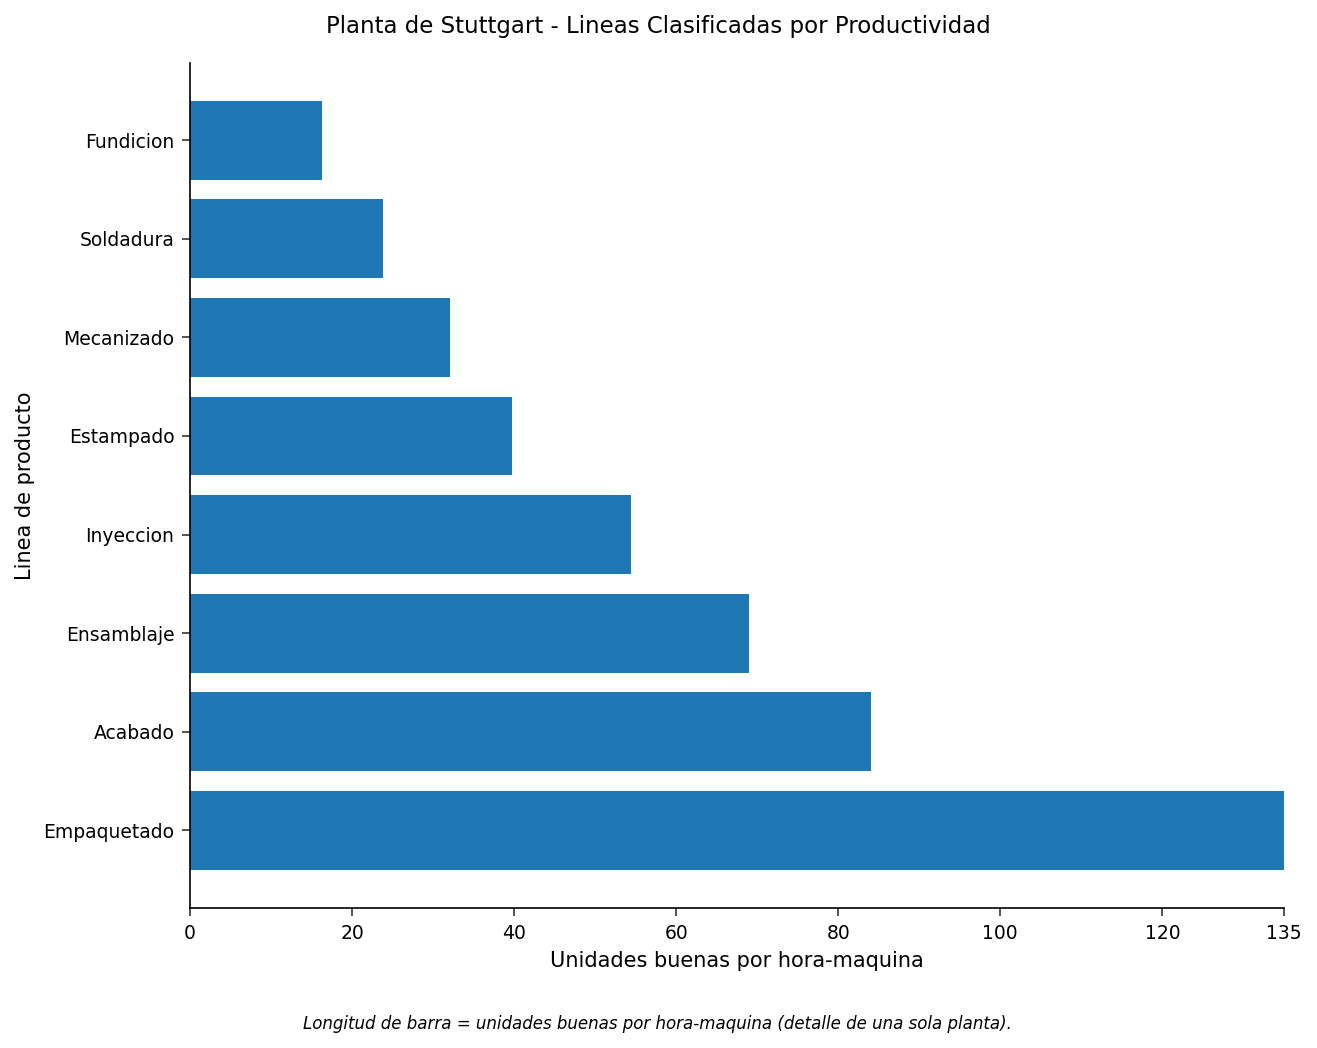

In [6]:
TÍTULO 'Planta de Stuttgart - Lineas Clasificadas por Productividad';
footnote JUSTIFY=LEFT 'Longitud de barra = unidades buenas por hora-maquina (detalle de una sola planta).';

PROCEDIMIENTO SGPLOT DATOS=work.line_capacity;
    DONDE plant = 'Stuttgart';
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS ETIQUETA='Unidades buenas por hora-maquina';
    YAXIS ETIQUETA='Linea de producto';
EJECUTAR;

TÍTULO; footnote;

## 7. Comparación de plantas lado a lado (barras agrupadas)

Para comparar las tres plantas línea por línea, un gráfico de barras agrupadas (`GROUPDISPLAY=CLUSTER`) dibuja Detroit, Monterrey y Stuttgart como barras adyacentes dentro de cada línea de producto. Esta es la vista de comparación directa de plantas: para cualquier línea puedes leer qué planta produjo más unidades buenas, haciendo directamente visibles las diferencias de eficiencia entre plantas (Stuttgart la más alta, Monterrey la más baja).

                                    Unidades Buenas por Linea y Planta - Lado a Lado                                    
                        Barras agrupadas: una barra por planta dentro de cada linea de producto                         




NOTE: Option TITLE changed to Unidades Buenas por Linea y Planta - Lado a Lado.
NOTE: Option TITLE2 changed to Barras agrupadas: una barra por planta dentro de cada linea de producto.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


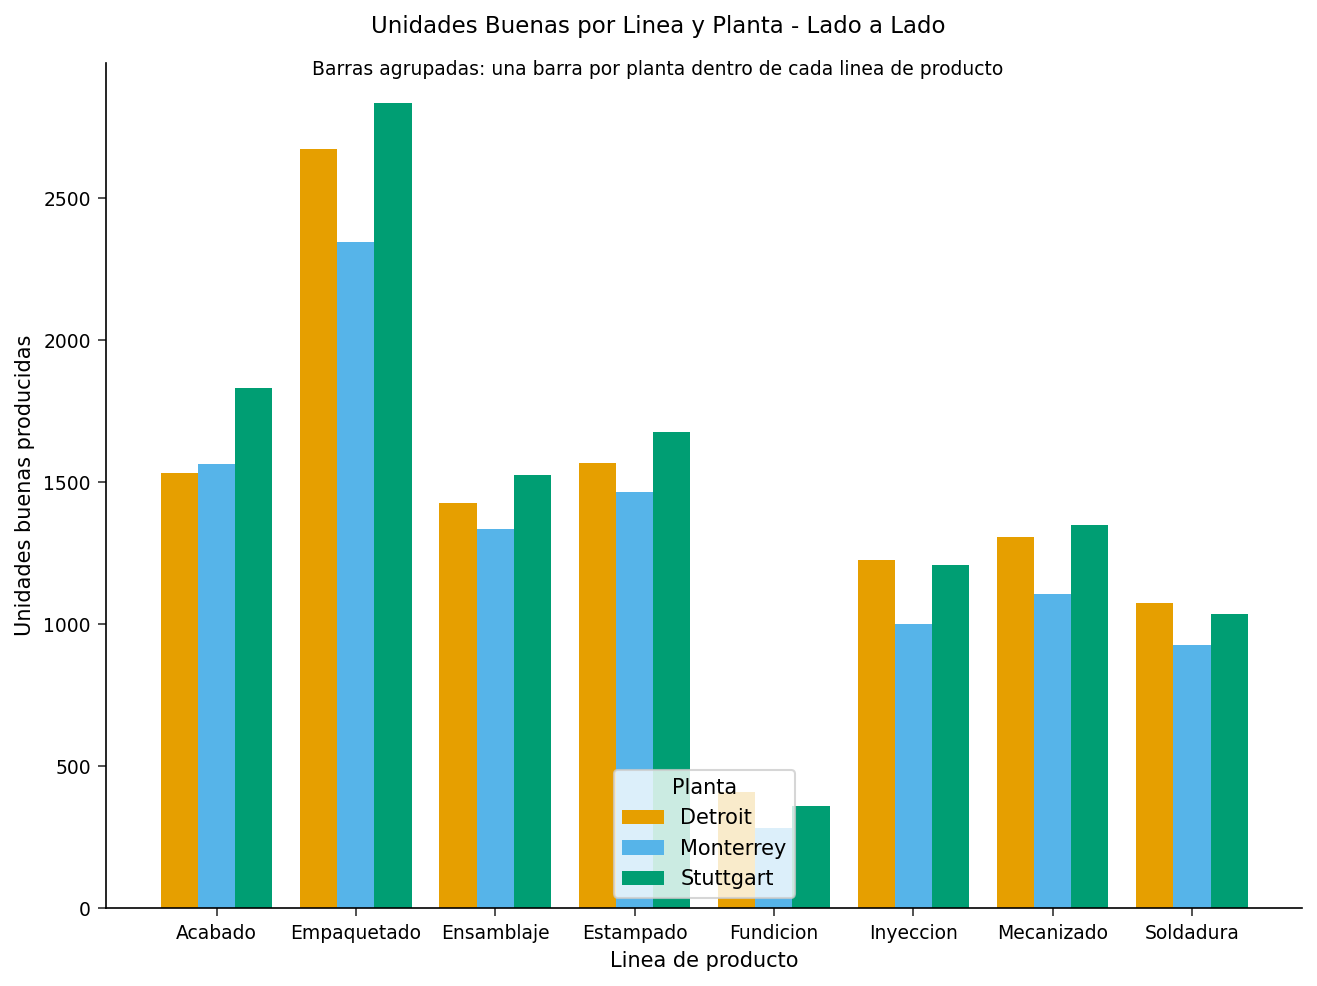

In [7]:
TÍTULO 'Unidades Buenas por Linea y Planta - Lado a Lado';
title2 'Barras agrupadas: una barra por planta dentro de cada linea de producto';

PROCEDIMIENTO SGPLOT DATOS=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS ETIQUETA='Linea de producto' fitpolicy=ROTATE;
    YAXIS ETIQUETA='Unidades buenas producidas';
    keylegend / TÍTULO='Planta' position=bottom;
EJECUTAR;

TÍTULO; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;

## Interpretación

Graficar capacidad y rendimiento en los mismos ejes expone una relación que un gráfico de barras unidimensional ocultaría. **Fundición** es el sumidero de capacidad más claro del portafolio: en la clasificación de productividad se ubica al fondo con **14.3 unidades buenas por hora-máquina**, y en el gráfico de burbujas cae hacia la parte inferior izquierda como una burbuja pequeña — consume **10.1%** de las horas programadas totales pero devuelve solo **3.2%** de las unidades buenas (también tiene el rendimiento más bajo, ~91%, por su alta fracción de desecho). Es la principal candidata para kaizen de reducción de tiempo de ciclo y desecho. En el extremo opuesto, **Empaquetado** es la línea de alto rendimiento sobresaliente con **119.2 unidades por hora-máquina** — una burbuja grande alta en el eje de rendimiento que convierte **9.1%** de la capacidad en **23.8%** de todas las unidades buenas; proteger su disponibilidad produce un rendimiento desproporcionado. **Acabado** (76.3 unidades/hora) y **Ensamblaje** (63.7) siguen el mismo patrón de alto rendimiento.

El patrón es sistemático: las cuatro líneas lentas y hambrientas de capacidad aguas arriba — Fundición, Soldadura (23.2 unidades/hora), Mecanizado (29.2) y Estampado (36.1) — consumen juntas aproximadamente **64%** de las horas programadas pero entregan solo cerca de **38%** de las unidades buenas, mientras que las cuatro líneas rápidas aguas abajo entregan más de lo esperado en relación con las horas que consumen. La vista apilada por planta y las barras agrupadas lado a lado muestran la dimensión de planta detrás de esto: **Stuttgart** funciona más caliente con **49.9 unidades buenas por hora-máquina**, **Detroit** está en el medio con **44.9**, y **Monterrey** queda rezagada con **41.6** — consistente con el mayor tiempo de inactividad modelado de Monterrey. Operativamente, esto apunta a reequilibrar las horas programadas hacia las líneas de alto rendimiento aguas abajo y comparar el tiempo de inactividad de Monterrey con las prácticas de Stuttgart.

*Solo datos sintéticos — las cifras son ilustrativas de la visualización bidimensional de capacidad vs. rendimiento con PROC SGPLOT, no del desempeño real de la planta.*